In [1]:
import matplotlib.pyplot as plt
from ete3 import NCBITaxa
import seaborn as sns
import pandas as pd
import numpy as np
import glob

Matplotlib created a temporary cache directory at /tmp/matplotlib-jfxlncoa because the default path (/software/anaconda3/envs/eb/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [5]:
home_path = '/cluster/raid/home/f80878961/'
script_path ='/cluster/raid/home/f80878961/scripts/'

extract_kraken_reads_script = '/cluster/raid/home/f80878961/scripts/KrakenTools/extract_kraken_reads.py'

In [3]:
# to disable ssl certificate check...
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [4]:
ncbi = NCBITaxa()
# ncbi.update_taxonomy_database()

## Kraken2 + Bracken

In [43]:
def write_kraken2_script(kraken2_script_fn):
    kraken2_runstr="""#!/bin/bash -l
#SBATCH --array=68,102,103,157-185
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --mem=400g
#SBATCH --time=02:00:00
#SBATCH --job-name=kbraken2
#SBATCH --output=%x_%A_%a.out
#SBATCH --error=%x_%A_%a.err

modulesld
ebld
module use /software/anaconda3/envs/eb/easybuild/modules/all
conda activate planb
which kraken2
which bracken

kdb_path=$1
kdb_name=$2
input_path=$3
output_path=$4

cd $output_path

# padding zeros
printf -v j "%04d" $SLURM_ARRAY_TASK_ID
sample_id=BS18-${j}

reads_1=$(ls ${input_path}${sample_id}*_R1.fastq.gz)
reads_2=$(ls ${input_path}${sample_id}*_R2.fastq.gz)
echo $reads_1
echo $reads_2

kraken2 --threads 8 --db ${kdb_path}${kdb_name} --paired --report-minimizer-data --minimum-hit-groups 4 --use-names --gzip-compressed --unclassified-out ${output_path}${sample_id}_ucseqs#.fq --classified-out ${output_path}${sample_id}_cseqs#.fq --output ${output_path}${sample_id}.kraken2 --report ${output_path}${sample_id}.k2report ${reads_1} ${reads_2}

bracken -d ${kdb_path}${kdb_name} -i ${output_path}${sample_id}.k2report -r 150 -l S -t 10 -o ${output_path}${sample_id}.bracken -w ${output_path}${sample_id}.breport

python /cluster/raid/home/f80878961/scripts/KrakenTools/filter_bracken.out.py -i ${output_path}${sample_id}.bracken -o ${output_path}${sample_id}_f.bracken --include 109461 7460"""
    with open(kraken2_script_fn, 'w') as outf:
        outf.write(kraken2_runstr)

In [44]:
script_path ='/cluster/raid/home/f80878961/scripts/'

kraken2_script = '{}kraken2_v2.run'.format(script_path)
write_kraken2_script(kraken2_script)

kdb_path = '/cluster/raid/home/f80878961/phenotypes/'
kdb_name = 'corent_krakdb'
input_path = '/cluster/raid/home/f80878961/phenotypes/SwissFastQSample/'
output_path = '/cluster/raid/home/f80878961/phenotypes/tmp/kraken2_corent/'

start script from Gamarello

In [45]:
%%bash -s "$kraken2_script" "$kdb_path" "$kdb_name" "$input_path" "$output_path"
cd $5
sbatch $1 $2 $3 $4 $5

Submitted batch job 43622


In [48]:
%%bash
sacct

JobID           JobName  Partition    Account  AllocCPUS      State ExitCode 
------------ ---------- ---------- ---------- ---------- ---------- -------- 
43130        jupyter-n+      nodes        ags          1    TIMEOUT      0:0 
43130.batch       batch                   ags          1  CANCELLED     0:15 
43130.extern     extern                   ags          1  COMPLETED      0:0 
43292_77       kbraken2      nodes        ags          1  COMPLETED      0:0 
43292_77.ba+      batch                   ags          1  COMPLETED      0:0 
43292_77.ex+     extern                   ags          1  COMPLETED      0:0 
43292_80       kbraken2      nodes        ags          1  COMPLETED      0:0 
43292_80.ba+      batch                   ags          1  COMPLETED      0:0 
43292_80.ex+     extern                   ags          1  COMPLETED      0:0 
43292_81       kbraken2      nodes        ags          1  COMPLETED      0:0 
43292_81.ba+      batch                   ags          1  COMPLE

## Bowtie2

In [133]:
def write_bowtie2_script(script_fn, array_str, r1_suffix, r2_suffix, out_name):
    runstr="""#!/bin/bash -l
#SBATCH --array={}
#SBATCH --nodes=1
#SBATCH --ntasks=8
#SBATCH --mem=30g
#SBATCH --time=04:00:00
#SBATCH --job-name=bowtie2
#SBATCH --output=%x_%A_%a.out
#SBATCH --error=%x_%A_%a.err

modulesld
ebld
module use /software/anaconda3/envs/eb/easybuild/modules/all
conda activate planb
ml Bowtie2
which bowtie2 

idx_path=$1
idx_name=$2
input_path=$3
output_path=$4

cd $output_path

# padding zeros
printf -v j "%04d" $SLURM_ARRAY_TASK_ID
sample_id=BS18-${{j}}

reads_1=$(ls ${{input_path}}${{sample_id}}{})
reads_2=$(ls ${{input_path}}${{sample_id}}{})
echo $reads_1
echo $reads_2

bowtie2 -x  ${{idx_path}}${{idx_name}} -p 8 -1 ${{reads_1}} -2 ${{reads_2}} --un-conc ${{output_path}}${{sample_id}}_${{idx_name}}_{}_unmapped.fastq -S ${{output_path}}${{sample_id}}_${{idx_name}}_{}_mapped.sam > ${{output_path}}${{sample_id}}_${{idx_name}}_{}.out 2>&1""".format(
    array_str, r1_suffix, r2_suffix, out_name, out_name, out_name)
    with open(script_fn, 'w') as outf:
        outf.write(runstr)

**Map to bee**

In [ ]:
%% bash
ls /cluster/raid/home/f80878961/phenotypes/bee_bt2idx/

In [51]:
script_path ='/cluster/raid/home/f80878961/scripts/'

bowtie2_script = '{}bowtie2_bee.run'.format(script_path)
write_bowtie2_script(bowtie2_script)

idx_path = '/cluster/raid/home/f80878961/phenotypes/bee_bt2idx/'
idx_name = 'bee'
input_path = '/cluster/raid/home/f80878961/phenotypes/SwissFastQSample/'
output_path = '/cluster/raid/home/f80878961/phenotypes/tmp/bowtie2/'

In [52]:
%%bash -s "$bowtie2_script" "$idx_path" "$idx_name" "$input_path" "$output_path"
cd $5
sbatch $1 $2 $3 $4 $5

Submitted batch job 43299


**Map to varroa**

In [55]:
script_path ='/cluster/raid/home/f80878961/scripts/'

bowtie2_script = '{}bowtie2_mite.run'.format(script_path)
write_bowtie2_script(bowtie2_script)

idx_path = '/cluster/raid/home/f80878961/phenotypes/mite_bt2idx/'
idx_name = 'mite'
input_path = '/cluster/raid/home/f80878961/phenotypes/SwissFastQSample/'
output_path = '/cluster/raid/home/f80878961/phenotypes/tmp/bowtie2/'

In [56]:
%%bash -s "$bowtie2_script" "$idx_path" "$idx_name" "$input_path" "$output_path"
cd $5
sbatch $1 $2 $3 $4 $5

Submitted batch job 43300


In [57]:
!sacct

JobID           JobName  Partition    Account  AllocCPUS      State ExitCode 
------------ ---------- ---------- ---------- ---------- ---------- -------- 
41114        jupyter-n+      nodes        ags          1    TIMEOUT      0:0 
41114.batch       batch                   ags          1  CANCELLED     0:15 
41114.extern     extern                   ags          1  COMPLETED      0:0 
43130        jupyter-n+      nodes        ags          1    RUNNING      0:0 
43130.batch       batch                   ags          1    RUNNING      0:0 
43130.extern     extern                   ags          1    RUNNING      0:0 
43199_2        kbraken2      nodes        ags          8  COMPLETED      0:0 
43199_2.bat+      batch                   ags          8  COMPLETED      0:0 
43199_2.ext+     extern                   ags          8  COMPLETED      0:0 
43233_2        kbraken2      nodes        ags          8  COMPLETED      0:0 
43233_2.bat+      batch                   ags          8  COMPLE

**Map to varroa mitochondrial genome**

## Varroa / bee relative abundance

In [ ]:
%%bash
grep Varroa /cluster/raid/home/f80878961/phenotypes/tmp/bracken/BS18-0027.bracken
grep Apis /cluster/raid/home/f80878961/phenotypes/tmp/bracken/BS18-0027.bracken

In [ ]:
%%bash
python /cluster/raid/home/f80878961/scripts/KrakenTools/filter_bracken.out.py -i /cluster/raid/home/f80878961/phenotypes/tmp/bracken/BS18-0027.bracken -o /cluster/raid/home/f80878961/phenotypes/tmp/bracken/BS18-0027_f.bracken --include 109461 7460 

In [ ]:
%%bash
cat /cluster/raid/home/f80878961/phenotypes/tmp/bracken/BS18-0027_f.bracken
cat /cluster/raid/home/f80878961/phenotypes/tmp/bracken/BS18-0001_f.bracken

In [3]:
# def parse_bracken_output(bracken_fn):
#     sp2record = {}
#     columns = None
#     with open(bracken_fn, 'r') as inf:
#         columns = inf.readline().rstrip().split('\t')
#         for l in inf:
#             sl = l.rstrip().split('\t')
#             sp2record[sl[0]] = (int(sl[1]), sl[2], int(sl[3]), int(sl[4]), int(sl[5]), float(sl[6]))tmp/kraken2_corent
#     return sp2record, columns

def get_sp_frac(bracken_fn, sp):
    df = pd.read_csv(bracken_fn, sep='\t')
    return float(df[df['name'] == sp]['fraction_total_reads'].values[0])

In [5]:
bracken_files = glob.glob('{}phenotypes/tmp/kraken2_corent/BS18-*_f.bracken'.format(home_path))
print(len(bracken_files))
for i in range(1, 185):
    file = '{}phenotypes/tmp/kraken2_corent/BS18-{}_f.bracken'.format(home_path, '%04d' % i) 
    if file not in bracken_files:
        print(file)

182
/cluster/raid/home/f80878961/phenotypes/tmp/kraken2_corent/BS18-0068_f.bracken
/cluster/raid/home/f80878961/phenotypes/tmp/kraken2_corent/BS18-0102_f.bracken
/cluster/raid/home/f80878961/phenotypes/tmp/kraken2_corent/BS18-0103_f.bracken


In [6]:
df_records = []
for f in sorted(bracken_files):
    df_records.append((f.split('/')[-1].rstrip('_f.bracken'), get_sp_frac(f, 'Varroa destructor')))

In [7]:
bracken_df = pd.DataFrame(df_records, columns=['name', 'varroaBrackenFrac'])

In [8]:
# parse Sonia data
mito_df = pd.read_csv('/cluster/raid/home/f80878961/phenotypes/varroa_seq_suisse.csv', sep=';', usecols=range(6))

In [17]:
mito_df[mito_df['name'] <= 'BS18-0185']

,name,chrDepth,beeMitoDepth,varroaMitoDepth,beeMitoratio,varroaMitoRatio
0,BS18-0007,39.596875,4252.96,0.59,107.406456,0.014900
1,BS18-0008,37.439375,4132.12,0.01,110.368295,0.000267
2,BS18-0009,38.300000,5013.72,2.08,130.906527,0.054308
3,BS18-0010,33.368750,3913.07,0.13,117.267503,0.003896
4,BS18-0011,35.825000,4026.15,0.27,112.383810,0.007537
...,...,...,...,...,...,...
103,BS18-0181,38.897500,13722.60,9.78,352.788740,0.251430
104,BS18-0182,33.086875,10553.64,7.65,318.967566,0.231210
105,BS18-0183,34.193125,12636.48,2.40,369.562010,0.070190
106,BS18-0184,26.661875,9369.93,0.99,351.435524,0.037132


In [60]:
mito_df[mito_df['name'] == 'BS18-0162']

,name,chrDepth,beeMitoDepth,varroaMitoDepth,beeMitoratio,varroaMitoRatio


In [9]:
# phenotype data
pheno_df = pd.read_csv('/cluster/raid/home/f80878961/phenotypes/phenotype_suisse.csv', sep=';')

In [38]:
# intersection between bracken and pheno data
brack_pheno_df = pd.merge(bracken_df, pheno_df.loc[:, ['N°-Ruche-BeeStrong', 'Nb varroas/100 bees']].rename(columns={'N°-Ruche-BeeStrong':'name'}), on='name')

In [39]:
# intersection between mito, pheno and bracken data
df = pd.merge(brack_pheno_df, mito_df, on='name')

In [ ]:
brack_pheno_df

In [61]:
mito_df[mito_df['name'] == 'BS18-0068']

,name,chrDepth,beeMitoDepth,varroaMitoDepth,beeMitoratio,varroaMitoRatio


In [62]:
df_left[df_left['name'] == 'BS18-0165']

,name,varroaBrackenFrac,Nb varroas/100 bees
163,BS18-0165,0.000145,27.35


In [63]:
df_left[df_left['name'] == 'BS18-0162']

,name,varroaBrackenFrac,Nb varroas/100 bees
160,BS18-0162,0.00145,43.77


In [56]:
brack_pheno_df[brack_pheno_df['Nb varroas/100 bees'] > 25]

,name,varroaBrackenFrac,Nb varroas/100 bees
26,BS18-0027,0.001863,28.06
82,BS18-0084,0.000558,26.38
157,BS18-0161,0.000796,27.49
158,BS18-0162,0.001450,43.77
161,BS18-0165,0.000145,27.35
162,BS18-0166,0.000931,33.59
163,BS18-0167,0.001037,41.96
164,BS18-0168,0.001040,40.32
173,BS18-0177,0.000934,31.56
175,BS18-0179,0.000869,30.70


In [57]:
df[df['Nb varroas/100 bees'] > 25]

,name,varroaBrackenFrac,Nb varroas/100 bees,chrDepth,beeMitoDepth,varroaMitoDepth,beeMitoratio,varroaMitoRatio
18,BS18-0027,0.001863,28.06,35.816875,14853.36,25.96,414.702846,0.724798
65,BS18-0084,0.000558,26.38,47.910000,6737.09,9.89,140.619704,0.206429
86,BS18-0161,0.000796,27.49,33.629375,4891.29,9.92,145.446949,0.294980
89,BS18-0166,0.000931,33.59,25.173125,4331.31,9.45,172.060878,0.375400
90,BS18-0167,0.001037,41.96,34.755000,4356.44,12.41,125.347144,0.357071
91,BS18-0168,0.001040,40.32,27.195000,4189.06,10.33,154.037875,0.379849
98,BS18-0177,0.000934,31.56,33.520625,13140.08,10.62,391.999851,0.316820
100,BS18-0179,0.000869,30.70,24.181250,8526.19,6.97,352.595089,0.288240
102,BS18-0182,0.000717,25.29,33.086875,10553.64,7.65,318.967566,0.231210


In [46]:
# get bracken + pheno data not in mito df 
outer = brack_pheno_df.merge(mito_df, how='outer', indicator=True)
df_left = outer[outer['_merge'] == 'left_only'].drop(outer.columns[3:], axis=1)

0.8978630768934069


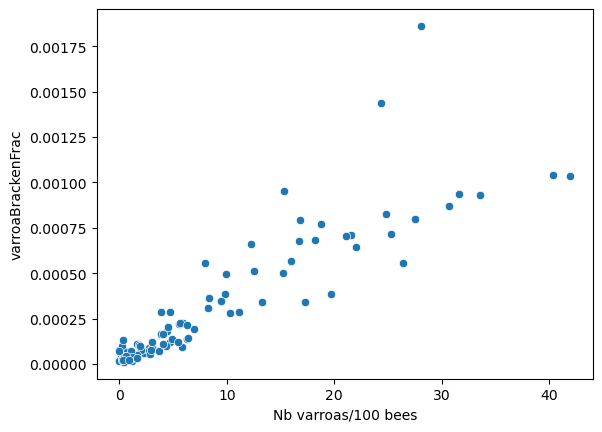

In [40]:
sns.scatterplot(data=df, x='Nb varroas/100 bees', y='varroaBrackenFrac')
print(df['Nb varroas/100 bees'].corr(df['varroaBrackenFrac']))

In [52]:
df[df['varroaBrackenFrac'] > 0.0009]

,name,varroaBrackenFrac,Nb varroas/100 bees,chrDepth,beeMitoDepth,varroaMitoDepth,beeMitoratio,varroaMitoRatio
18,BS18-0027,0.001863,28.06,35.816875,14853.36,25.96,414.702846,0.724798
88,BS18-0164,0.001437,24.31,32.588750,5268.78,15.65,161.674811,0.480227
89,BS18-0166,0.000931,33.59,25.173125,4331.31,9.45,172.060878,0.375400
90,BS18-0167,0.001037,41.96,34.755000,4356.44,12.41,125.347144,0.357071
91,BS18-0168,0.001040,40.32,27.195000,4189.06,10.33,154.037875,0.379849
98,BS18-0177,0.000934,31.56,33.520625,13140.08,10.62,391.999851,0.316820
105,BS18-0185,0.000955,15.31,44.133125,13151.00,14.46,297.984790,0.327645


0.8883358364539262


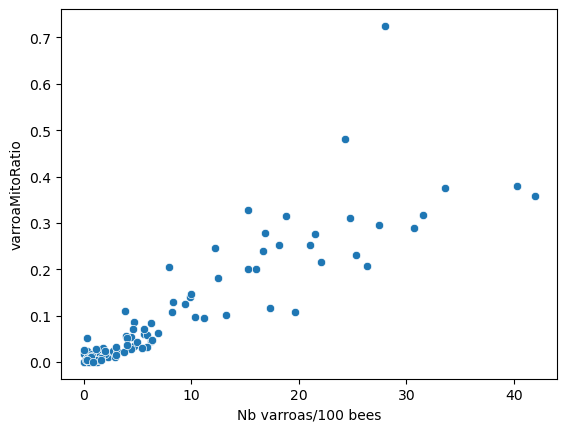

In [28]:
sns.scatterplot(data=df, x='Nb varroas/100 bees', y='varroaMitoRatio')
print(df['Nb varroas/100 bees'].corr(df['varroaMitoRatio']))

0.9957577897908169


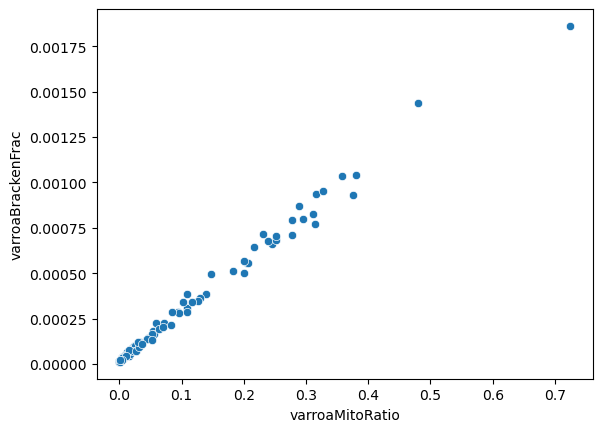

In [32]:
sns.scatterplot(data=df, x='varroaMitoRatio', y='varroaBrackenFrac')
print(df['varroaMitoRatio'].corr(df['varroaBrackenFrac']))

(0.0, 0.00025)

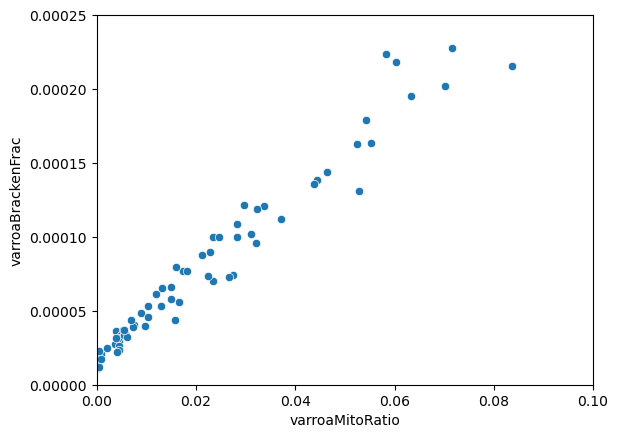

In [34]:
sns.scatterplot(data=df, x='varroaMitoRatio', y='varroaBrackenFrac')
plt.xlim(0, 0.1)
plt.ylim(0, 0.00025)

0.8968604254514174


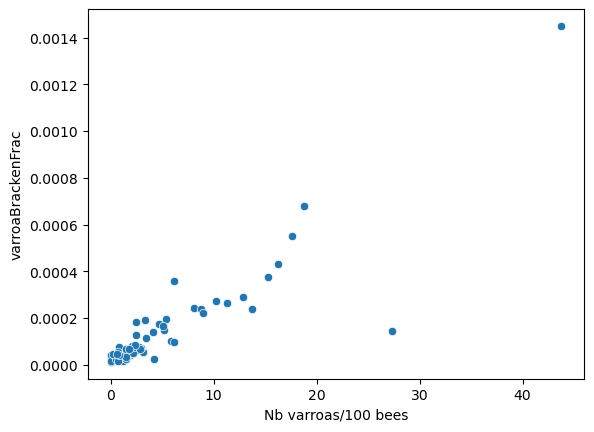

In [49]:
sns.scatterplot(data=df_left, x='Nb varroas/100 bees', y='varroaBrackenFrac')
print(df_left['Nb varroas/100 bees'].corr(df_left['varroaBrackenFrac']))


(0.0, 0.0004)

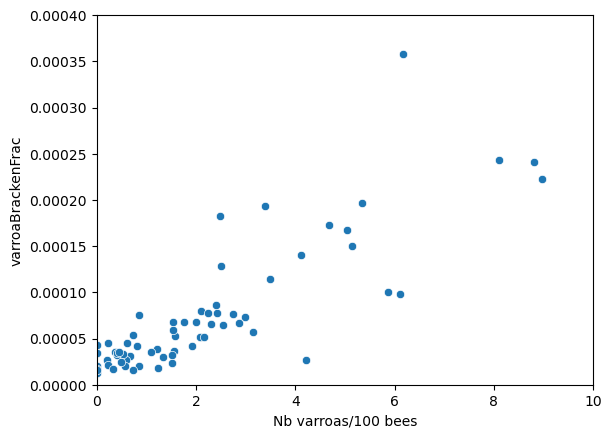

In [51]:
sns.scatterplot(data=df_left, x='Nb varroas/100 bees', y='varroaBrackenFrac')
plt.xlim(0, 10)
plt.ylim(0, 0.0004)

## Extract varroa reads

In [12]:
def get_args_extract_reads(bs_id, taxon, kraken_path, read_path):

    # pad 0 before number
    bs_id_str = '%04d' % bs_id

    # get string of taxonomic ids
    name2taxid = ncbi.get_name_translator([taxon])
    taxids = ncbi.get_descendant_taxa(name2taxid[taxon][0], intermediate_nodes=True)
    taxids_str = ' '.join([str(x) for x in taxids])

    kraken_outf = '{}BS18-{}.kraken2'.format(kraken_path, bs_id_str)
    reads_1 = glob.glob('{}BS18-{}_*_R1.fastq.gz'.format(read_path, bs_id_str))[0]
    reads_2 = glob.glob('{}BS18-{}_*_R2.fastq.gz'.format(read_path, bs_id_str))[0]
    out_reads_1 = '{}BS18-{}_{}_R1.fq'.format(kraken_path, bs_id_str, taxon.replace(' ', '_'))
    out_reads_2 = '{}BS18-{}_{}_R2.fq'.format(kraken_path, bs_id_str, taxon.replace(' ', '_'))

    return kraken_outf, reads_1,reads_2, out_reads_1, out_reads_2, taxids_str

In [13]:
kraken_outf, reads_1,reads_2, out_reads_1, out_reads_2, taxids_str = get_args_extract_reads(
    27, 'Varroa destructor', '/cluster/raid/home/f80878961/phenotypes/tmp/kraken2_corent/', '{}phenotypes/SwissFastQSample/'.format(home_path))

In [17]:
%%bash -s "$extract_kraken_reads_script" "$kraken_outf" "$reads_1" "$reads_2" "$out_reads_1" "$out_reads_2" "$taxids_str"
python $1 -k $2 -1 $3 -2 $4 -o $5 -o2 $6 --fastq-output -t $7

PROGRAM START TIME: 02-14-2025 10:52:21
	1 taxonomy IDs to parse
>> STEP 1: PARSING KRAKEN FILE FOR READIDS /cluster/raid/home/f80878961/phenotypes/tmp/kraken2_corent/BS18-0027.kraken2
	35.87 million reads processed
	10835 read IDs saved
>> STEP 2: READING SEQUENCE FILES AND WRITING READS
	10835 read IDs found (35.87 mill reads processed)
	10835 read IDs found (35.87 mill reads processed)
	10835 reads printed to file
	Generated file: /cluster/raid/home/f80878961/phenotypes/tmp/kraken2_corent/BS18-0027_Varroa_destructor_R1.fq
	Generated file: /cluster/raid/home/f80878961/phenotypes/tmp/kraken2_corent/BS18-0027_Varroa_destructor_R2.fq
PROGRAM END TIME: 02-14-2025 11:06:52


In [21]:
!tail /cluster/raid/home/f80878961/phenotypes/tmp/kraken2_corent/BS18-0027_Varroa_destructor_R2.fq

+
FFFFFFFFFFFFFFFFFF:FFFFFFFFFFFFFFFFFF:FFFFFFFFFFFFFFFFFFFFFFFFF:F#FFFFFFFFFFFF:FF,FFFFFFF:FFFFFFFFFFFFFFF:FFFFFFFFFFFFF::FFF:FFFFFFF:F,:FFFFF:FFFFFF,F
@A00318:36:HLGV2DSXX:1:2678:19388:36260 2:N:0:GTCGGAGC+GGTTATAA
TTATATAAATTCTTCTTTTTATATTATAAATAAGATTTTATTTTGAATTTTTGTAAATATTTTTANTATATTAACTTTCTTGGGATCGTGTCCTGTAGAAAGACCTTATATTTTATTAAGTCAAATTTATACAATTATGTATTTTATTTA
+
FFFFFFFFFFFFFFFFFFFFFFFFFFFFF:FFFFFFFF:FFFFFF,F,FFFFFFFFFFFFFFF:F#,FFFFFF,FFFFFFFFFFFFFFFFFFFFFFFF::FF,FFFFFFFFF:FFFF:FFFFFF::F,FFF,FFFFF:FFFFFFFFFFF:
@A00318:36:HLGV2DSXX:1:2678:15474:36307 2:N:0:GTCGGAGC+GGTTATAA
TCTTATACTTTCTTTTTGGATGATAATTTATTTTCCTTTTTCAAAGGGTAAGAGCATTAATTATGNATTTTTAATATTCTTATTTATTTCAAGTATAAGAATTTATCCTATTATTTTTAGTGGTTGATCTTCTAATTCTAAATATTCTAT
+
FFFFFFFFF,FFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFF#FFFFFF:FFFFFFFFFFFFFFFFF:FFFFFFFFF:FFFFFFFFFFFFFFFFFFFF:FFFF:FFFFFFFFF:FFFFF:F:,FF:F


In [19]:
!sacct


JobID           JobName  Partition    Account  AllocCPUS      State ExitCode 
------------ ---------- ---------- ---------- ---------- ---------- -------- 
46979        jupyter-n+      nodes        ags          1    RUNNING      0:0 
46979.batch       batch                   ags          1    RUNNING      0:0 
46979.extern     extern                   ags          1    RUNNING      0:0 


## What are these timema placements?

In [108]:
extract_kraken_reads_script = '/cluster/raid/home/f80878961/scripts/KrakenTools/extract_kraken_reads.py'

In [109]:
bs_id = 27
bs_id_str = '%04d' % bs_id
bs_id_str

'0027'

In [110]:
taxon = 'Timema'
name2taxid = ncbi.get_name_translator([taxon])
taxids = ncbi.get_descendant_taxa(name2taxid[taxon][0], intermediate_nodes=True)
taxids_str = ' '.join([str(x) for x in taxids])

In [111]:
kraken_out_path = '/cluster/raid/home/f80878961/phenotypes/tmp/kraken2_corent/'
kraken_outf = '{}BS18-{}.kraken2'.format(kraken_out_path, bs_id_str)
reads_1 = glob.glob('{}phenotypes/SwissFastQSample/BS18-{}_*_R1.fastq.gz'.format(home_path, bs_id_str))[0]
reads_2 = glob.glob('{}phenotypes/SwissFastQSample/BS18-{}_*_R2.fastq.gz'.format(home_path, bs_id_str))[0]
out_reads_1 = '{}BS18-{}_{}_R1.fq'.format(kraken_out_path, bs_id_str, taxon)
out_reads_2 = '{}BS18-{}_{}_R2.fq'.format(kraken_out_path, bs_id_str, taxon)

In [114]:
%%bash -s "$extract_kraken_reads_script" "$kraken_outf" "$reads_1" "$reads_2" "$out_reads_1" "$out_reads_2" "$taxids_str"
python $1 -k $2 -1 $3 -2 $4 -o $5 -o2 $6 --fastq-output -t $7

PROGRAM START TIME: 02-11-2025 15:53:45
	23 taxonomy IDs to parse
>> STEP 1: PARSING KRAKEN FILE FOR READIDS /cluster/raid/home/f80878961/phenotypes/tmp/kraken2_corent/BS18-0027.kraken2
	35.87 million reads processed
	282810 read IDs saved
>> STEP 2: READING SEQUENCE FILES AND WRITING READS
	282810 read IDs found (35.87 mill reads processed)
	282810 read IDs found (35.87 mill reads processed)
	282810 reads printed to file
	Generated file: /cluster/raid/home/f80878961/phenotypes/tmp/kraken2_corent/BS18-0027_Timema_R1.fq
	Generated file: /cluster/raid/home/f80878961/phenotypes/tmp/kraken2_corent/BS18-0027_Timema_R2.fq
PROGRAM END TIME: 02-11-2025 16:09:07


In [134]:
bowtie2_script = '{}bowtie2_bee.run'.format(script_path)
write_bowtie2_script(bowtie2_script, '27', '_Timema_R1.fq', '_Timema_R2.fq', 'Timema')

In [149]:
!cat $bowtie2_script

#!/bin/bash -l
#SBATCH --array=27
#SBATCH --nodes=1
#SBATCH --ntasks=8
#SBATCH --mem=30g
#SBATCH --time=04:00:00
#SBATCH --job-name=bowtie2
#SBATCH --output=%x_%A_%a.out
#SBATCH --error=%x_%A_%a.err

modulesld
ebld
module use /software/anaconda3/envs/eb/easybuild/modules/all
conda activate planb
ml Bowtie2
which bowtie2 

idx_path=$1
idx_name=$2
input_path=$3
output_path=$4

cd $output_path

# padding zeros
printf -v j "%04d" $SLURM_ARRAY_TASK_ID
sample_id=BS18-${j}

reads_1=$(ls ${input_path}${sample_id}_Timema_R1.fq)
reads_2=$(ls ${input_path}${sample_id}_Timema_R2.fq)
echo $reads_1
echo $reads_2

bowtie2 -x  ${idx_path}${idx_name} -p 8 -1 ${reads_1} -2 ${reads_2} --un-conc ${output_path}${sample_id}_${idx_name}_Timema_unmapped.fastq -S ${output_path}${sample_id}_${idx_name}_Timema_mapped.sam > ${output_path}${sample_id}_${idx_name}_Timema.out 2>&1

In [136]:
idx_path = '/cluster/raid/home/f80878961/phenotypes/bee_bt2idx/'
idx_name = 'bee'
input_path = kraken_out_path
output_path = kraken_out_path

align timema reads on bee

In [137]:
%%bash -s "$bowtie2_script" "$idx_path" "$idx_name" "$input_path" "$output_path"
cd $5
sbatch $1 $2 $3 $4 $5

Submitted batch job 45568


and on varroa

In [151]:
idx_path = '/cluster/raid/home/f80878961/phenotypes/mite_bt2idx/'
idx_name = 'mite'
input_path = kraken_out_path
output_path = kraken_out_path

In [152]:
%%bash -s "$bowtie2_script" "$idx_path" "$idx_name" "$input_path" "$output_path"
cd $5
sbatch $1 $2 $3 $4 $5

Submitted batch job 45570


In [154]:
%%bash
sacct


JobID           JobName  Partition    Account  AllocCPUS      State ExitCode 
------------ ---------- ---------- ---------- ---------- ---------- -------- 
45326        jupyter-n+      nodes        ags          1    RUNNING      0:0 
45326.batch       batch                   ags          1    RUNNING      0:0 
45326.extern     extern                   ags          1    RUNNING      0:0 
45488              bash      nodes        ags          1    RUNNING      0:0 
45488.extern     extern                   ags          1    RUNNING      0:0 
45488.0            bash                   ags          1    RUNNING      0:0 
45568_27        bowtie2      nodes        ags          8  COMPLETED      0:0 
45568_27.ba+      batch                   ags          8  COMPLETED      0:0 
45568_27.ex+     extern                   ags          8  COMPLETED      0:0 
45569_27        bowtie2      nodes        ags          8  COMPLETED      0:0 
45569_27.ba+      batch                   ags          8  COMPLE